In [17]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.manifold import TSNE
from sklearn.preprocessing import StandardScaler

plt.style.use("seaborn-v0_8-whitegrid")
RANDOM_STATE = 42

TRAIN_DIR = "../../../Gait-Datasets-TIFS20/Dataset #1/train"
SIGNALS_DIR = f"{TRAIN_DIR}/Inertial Signals"
Y_PATH = f"{TRAIN_DIR}/y_train.txt"

CHANNEL_FILES = {
    "ACCx": "train_acc_x",
    "ACCy": "train_acc_y",
    "ACCz": "train_acc_z",
    "GYRx": "train_gyr_x",
    "GYRy": "train_gyr_y",
    "GYRz": "train_gyr_z",
}

In [18]:
def load_signal(file_name: str) -> np.ndarray:
    return pd.read_csv(
        f"{SIGNALS_DIR}/{file_name}.txt", sep=r"\s+", header=None
    ).to_numpy()

signals = {label: load_signal(file_name) for label, file_name in CHANNEL_FILES.items()}
y = pd.read_csv(Y_PATH, header=None).squeeze("columns").to_numpy(dtype=int)

X = np.concatenate(list(signals.values()), axis=1)

print(f"Using train data from: {TRAIN_DIR}")
print(f"Participants: {len(y)}")
print(f"Feature matrix shape: {X.shape}")

Using train data from: ../../../Gait-Datasets-TIFS20/Dataset #1/train
Participants: 33104
Feature matrix shape: (33104, 768)


,signal,missing_values,missing_pct
0,ACCx,0,0.0
1,ACCy,0,0.0
2,ACCz,0,0.0
3,GYRx,0,0.0
4,GYRy,0,0.0
5,GYRz,0,0.0
6,y_train,0,0.0


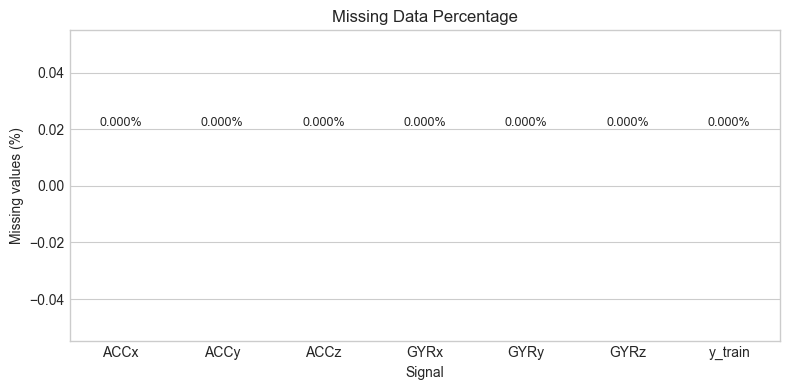

In [19]:
missing_rows = []

for label, arr in signals.items():
    missing_rows.append(
        {
            "signal": label,
            "missing_values": int(np.isnan(arr).sum()),
            "missing_pct": float(np.isnan(arr).mean() * 100),
        }
    )

missing_rows.append(
    {
        "signal": "y_train",
        "missing_values": int(np.isnan(y).sum()),
        "missing_pct": float(np.isnan(y).mean() * 100),
    }
)

missing_df = pd.DataFrame(missing_rows)
display(missing_df)

fig, ax = plt.subplots(figsize=(8, 4))
sns.barplot(data=missing_df, x="signal", y="missing_pct", color="#2E86AB", ax=ax)
ax.set_title("Missing Data Percentage")
ax.set_xlabel("Signal")
ax.set_ylabel("Missing values (%)")

for i, pct in enumerate(missing_df["missing_pct"]):
    ax.text(i, pct + 0.02, f"{pct:.3f}%", ha="center", va="bottom", fontsize=9)

plt.tight_layout()
plt.show()

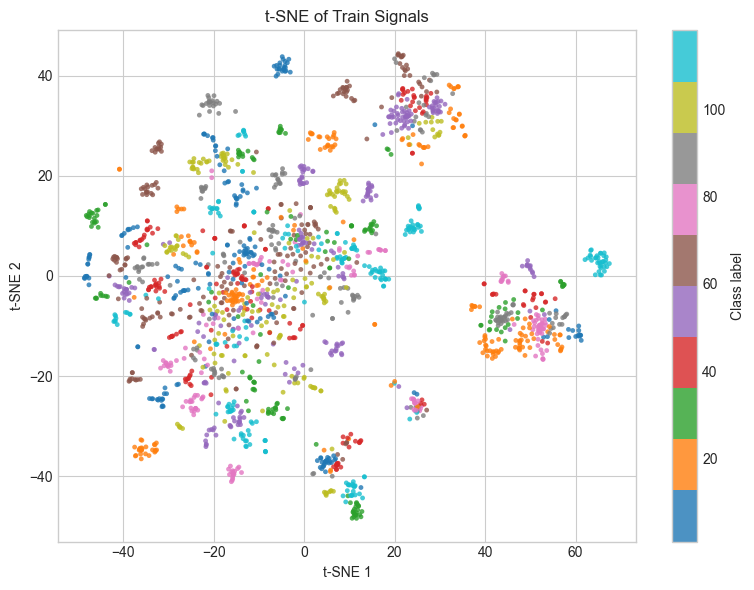

t-SNE input shape: (2000, 768)


In [20]:
max_samples = 2000
if X.shape[0] > max_samples:
    rng = np.random.default_rng(RANDOM_STATE)
    idx = rng.choice(X.shape[0], size=max_samples, replace=False)
    X_sel = X[idx]
    y_sel = y[idx]
else:
    X_sel = X
    y_sel = y

X_scaled = StandardScaler().fit_transform(X_sel)

tsne = TSNE(
    n_components=2,
    perplexity=30,
    learning_rate="auto",
    init="pca",
    random_state=RANDOM_STATE,
)
X_emb = tsne.fit_transform(X_scaled)

fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    X_emb[:, 0],
    X_emb[:, 1],
    c=y_sel,
    s=12,
    cmap="tab10",
    alpha=0.8,
    linewidths=0,
    rasterized=True,
)
ax.set_title("t-SNE of Train Signals")
ax.set_xlabel("t-SNE 1")
ax.set_ylabel("t-SNE 2")
cbar = plt.colorbar(scatter, ax=ax)
cbar.set_label("Class label")
plt.tight_layout()
plt.show()

print(f"t-SNE input shape: {X_sel.shape}")

Channel table shape (flattened): (4237312, 6)


,ACCx,ACCy,ACCz,GYRx,GYRy,GYRz
ACCx,1.000000,-0.074454,-0.048841,-0.021013,-0.002195,-0.229118
ACCy,-0.074454,1.000000,0.153031,0.072795,0.005148,-0.022578
ACCz,-0.048841,0.153031,1.000000,0.355484,0.071218,0.037269
GYRx,-0.021013,0.072795,0.355484,1.000000,0.006929,-0.004377
GYRy,-0.002195,0.005148,0.071218,0.006929,1.000000,0.034754
GYRz,-0.229118,-0.022578,0.037269,-0.004377,0.034754,1.000000


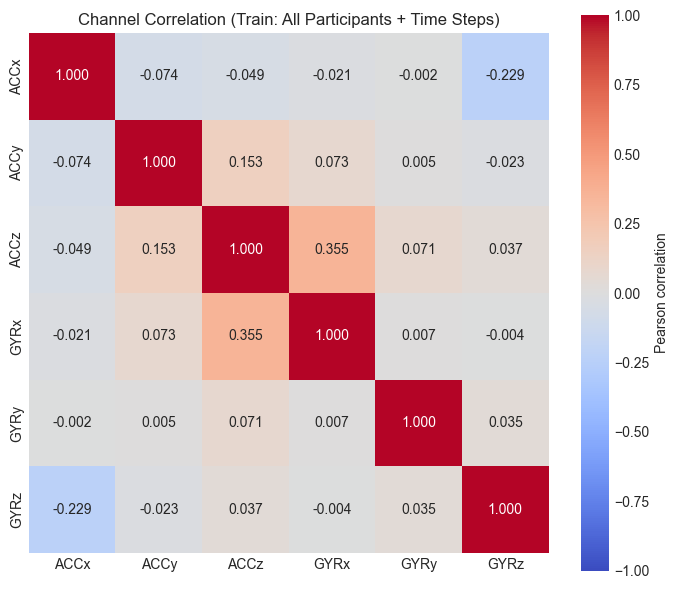

In [ ]:
channel_df = pd.DataFrame({label: arr.reshape(-1) for label, arr in signals.items()})
corr_channels = channel_df.corr(method="pearson")

print(f"Channel table shape (flattened): {channel_df.shape}")
display(corr_channels)

plt.figure(figsize=(7, 6))
sns.heatmap(
    corr_channels,
    annot=True,
    fmt=".3f",
    cmap="coolwarm",
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    cbar_kws={"label": "Pearson correlation"},
)
plt.title("Channel Correlation (Train: All Participants + Time Steps)")
plt.tight_layout()
plt.show()